<a href="https://colab.research.google.com/github/godara97/northstar-urban-mobility-analysis/blob/main/r_notebooks/04_r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# installing packages needed for r analytics
install.packages("ggplot2")
install.packages("dplyr")
install.packages("corrplot")

cat("packages installed!\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



packages installed!


In [4]:
# loading libraries
library(ggplot2)
library(dplyr)
library(corrplot)

customers  <- read.csv('customers.csv')
orders     <- read.csv('orders.csv')
deliveries <- read.csv('deliveries.csv')
drivers    <- read.csv('drivers.csv')
vehicles   <- read.csv('vehicles.csv')
incidents  <- read.csv('incidents.csv')
complaints <- read.csv('complaints.csv')
app_events <- read.csv('app_events.csv')

cat("all files loaded!\n")
cat("ready for analysis!\n")

all files loaded!
ready for analysis!


In [5]:
fix_zone <- function(x) {
  x <- trimws(tolower(x))
  ifelse(x %in% c("airport", "airprt"), "Airport",
  ifelse(x %in% c("north", "nrth"), "North",
  ifelse(x %in% c("south", "sth"), "South",
  ifelse(x %in% c("central", "ctr", "ctrl"), "Central",
  ifelse(x %in% c("east"), "East",
  ifelse(x %in% c("west"), "West",
  ifelse(x %in% c("riverside", "riversd"), "Riverside",
  x)))))))
}

customers$home_zone    <- fix_zone(customers$home_zone)
orders$pickup_zone     <- fix_zone(orders$pickup_zone)
orders$dropoff_zone    <- fix_zone(orders$dropoff_zone)
drivers$base_zone      <- fix_zone(drivers$base_zone)
vehicles$assigned_zone <- fix_zone(vehicles$assigned_zone)


customers$loyalty_score[is.na(customers$loyalty_score)] <- mean(customers$loyalty_score, na.rm=TRUE)
drivers$training_score[is.na(drivers$training_score)]   <- mean(drivers$training_score, na.rm=TRUE)
vehicles$battery_health_pct[is.na(vehicles$battery_health_pct)] <- mean(vehicles$battery_health_pct, na.rm=TRUE)
complaints$compensation_amount[is.na(complaints$compensation_amount)] <- mean(complaints$compensation_amount, na.rm=TRUE)
incidents$resolved_hours[is.na(incidents$resolved_hours)] <- mean(incidents$resolved_hours, na.rm=TRUE)

cat("data cleaned and ready!\n")

data cleaned and ready!


## R Analytics - NorthStar Urban Mobility
In this notebook I will use R to perform statistical
analysis and create visualisations to understand
NorthStar's operational problems better.

## Chart 1 - Delivery Performance by Zone
I want to see how each zone performs in terms of
on time, delayed and failed deliveries.

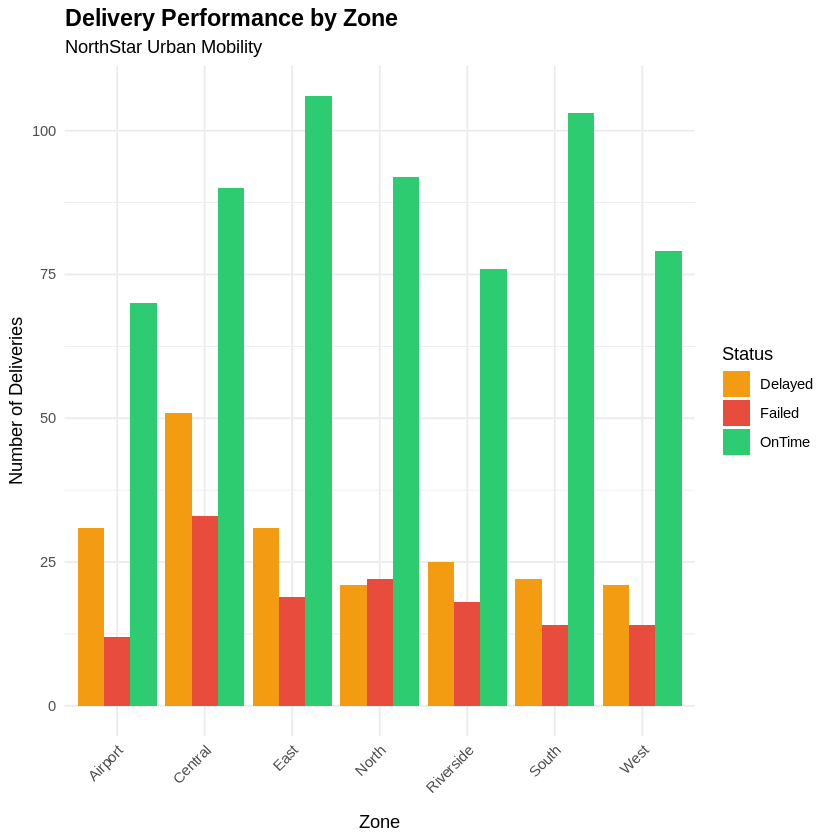

In [6]:
# first merge deliveries with orders to get zone info
merged <- merge(deliveries,
                orders[, c("order_id", "pickup_zone")],
                by="order_id")

# count deliveries by zone and status
zone_status <- merged %>%
  group_by(pickup_zone, delivery_status) %>%
  summarise(count = n(), .groups='drop')

ggplot(zone_status, aes(x=pickup_zone, y=count, fill=delivery_status)) +
  geom_bar(stat="identity", position="dodge") +
  scale_fill_manual(values=c("Failed"="#e74c3c",
                              "Delayed"="#f39c12",
                              "OnTime"="#2ecc71")) +
  labs(title="Delivery Performance by Zone",
       subtitle="NorthStar Urban Mobility",
       x="Zone",
       y="Number of Deliveries",
       fill="Status") +
  theme_minimal() +
  theme(plot.title=element_text(face="bold", size=14),
        axis.text.x=element_text(angle=45, hjust=1))

## Chart 2 - Driver Rating Distribution
How are driver ratings spread across the workforce?
Are most drivers rated well or is there a problem?

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


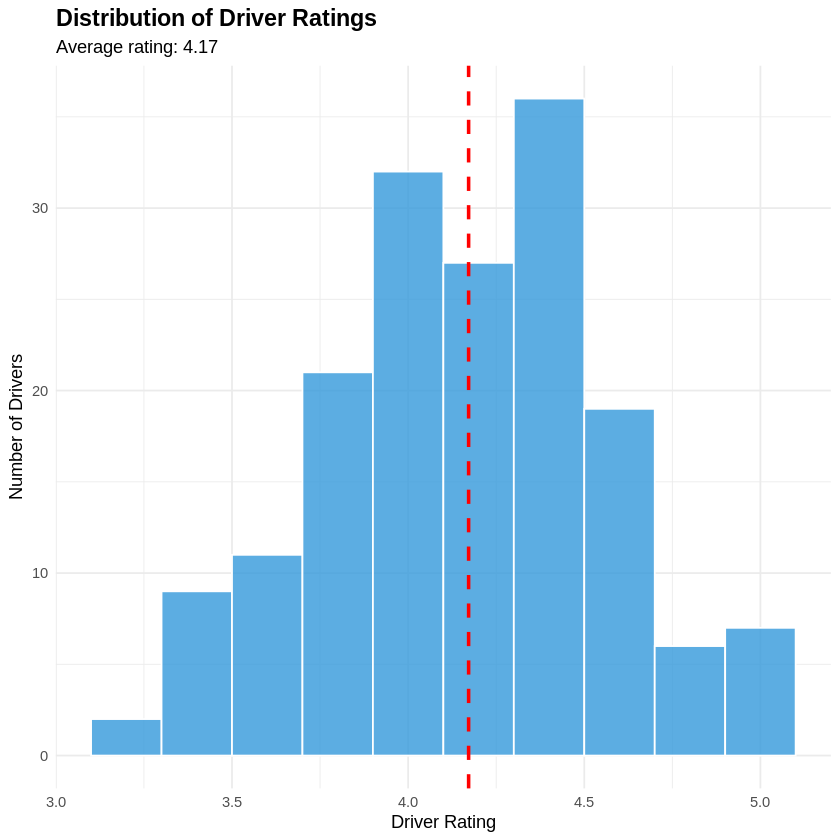

In [7]:
# histogram showing distribution of driver ratings

ggplot(drivers, aes(x=driver_rating)) +
  geom_histogram(binwidth=0.2,
                 fill="#3498db",
                 color="white",
                 alpha=0.8) +
  geom_vline(aes(xintercept=mean(driver_rating)),
             color="red",
             linetype="dashed",
             size=1) +
  labs(title="Distribution of Driver Ratings",
       subtitle=paste("Average rating:",
                      round(mean(drivers$driver_rating), 2)),
       x="Driver Rating",
       y="Number of Drivers") +
  theme_minimal() +
  theme(plot.title=element_text(face="bold", size=14))

## Chart 3 - Complaint Severity by Type
I want to understand which complaint types are
most severe and need urgent attention.

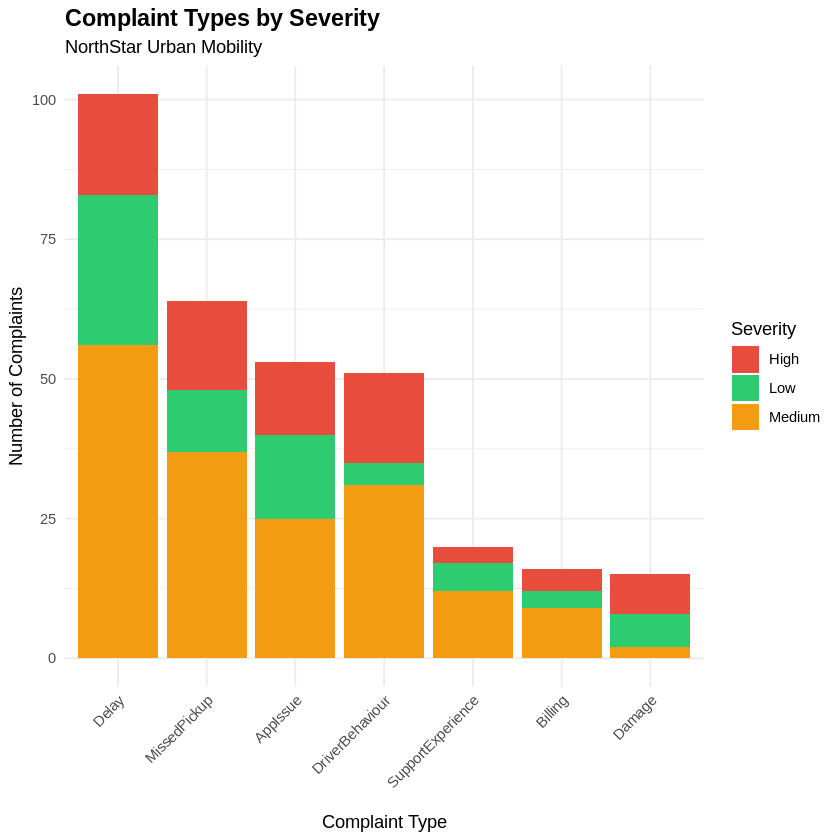

In [8]:
# stacked bar chart showing severity breakdown per complaint type

complaint_summary <- complaints %>%
  group_by(complaint_type, severity) %>%
  summarise(count=n(), .groups='drop')

ggplot(complaint_summary,
       aes(x=reorder(complaint_type, -count),
           y=count,
           fill=severity)) +
  geom_bar(stat="identity") +
  scale_fill_manual(values=c("High"="#e74c3c",
                              "Medium"="#f39c12",
                              "Low"="#2ecc71")) +
  labs(title="Complaint Types by Severity",
       subtitle="NorthStar Urban Mobility",
       x="Complaint Type",
       y="Number of Complaints",
       fill="Severity") +
  theme_minimal() +
  theme(plot.title=element_text(face="bold", size=14),
        axis.text.x=element_text(angle=45, hjust=1))

## Chart 4 - Training Score vs Driver Rating
Does better training lead to better driver ratings?
I will use a scatter plot to check this relationship.

`geom_smooth()` using formula = 'y ~ x'


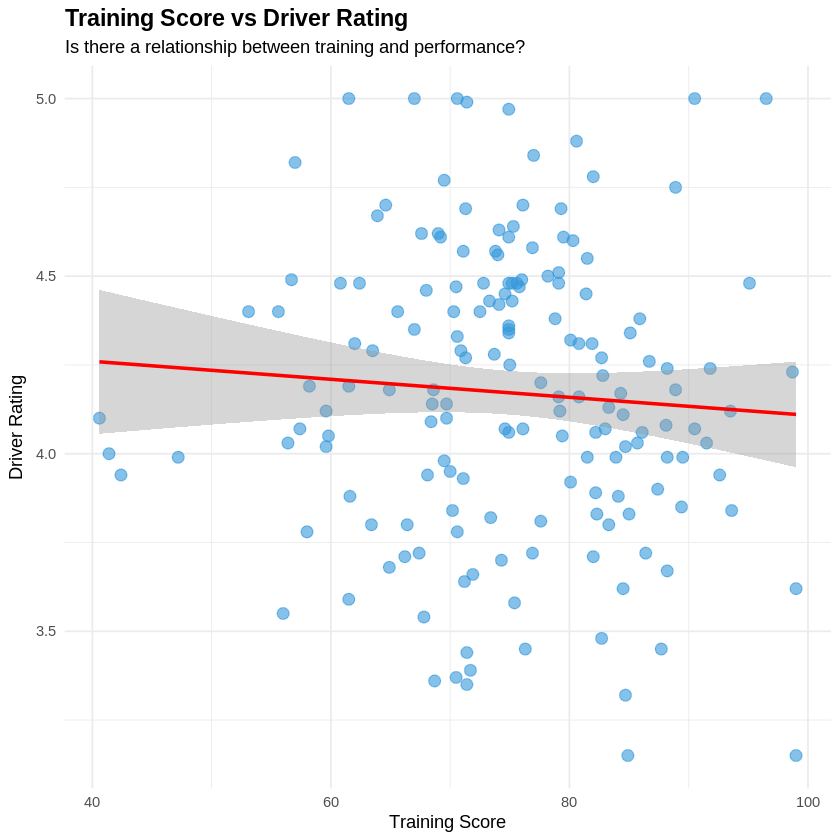

In [9]:
# scatter plot with trend line
# checking if training score predicts driver rating

ggplot(drivers, aes(x=training_score, y=driver_rating)) +
  geom_point(color="#3498db", alpha=0.6, size=3) +
  geom_smooth(method="lm", color="red", se=TRUE) +
  labs(title="Training Score vs Driver Rating",
       subtitle="Is there a relationship between training and performance?",
       x="Training Score",
       y="Driver Rating") +
  theme_minimal() +
  theme(plot.title=element_text(face="bold", size=14))

## Chart 5 - Customer Loyalty Score by Zone
Which zones have the most loyal customers?
This helps NorthStar know where to focus retention efforts.

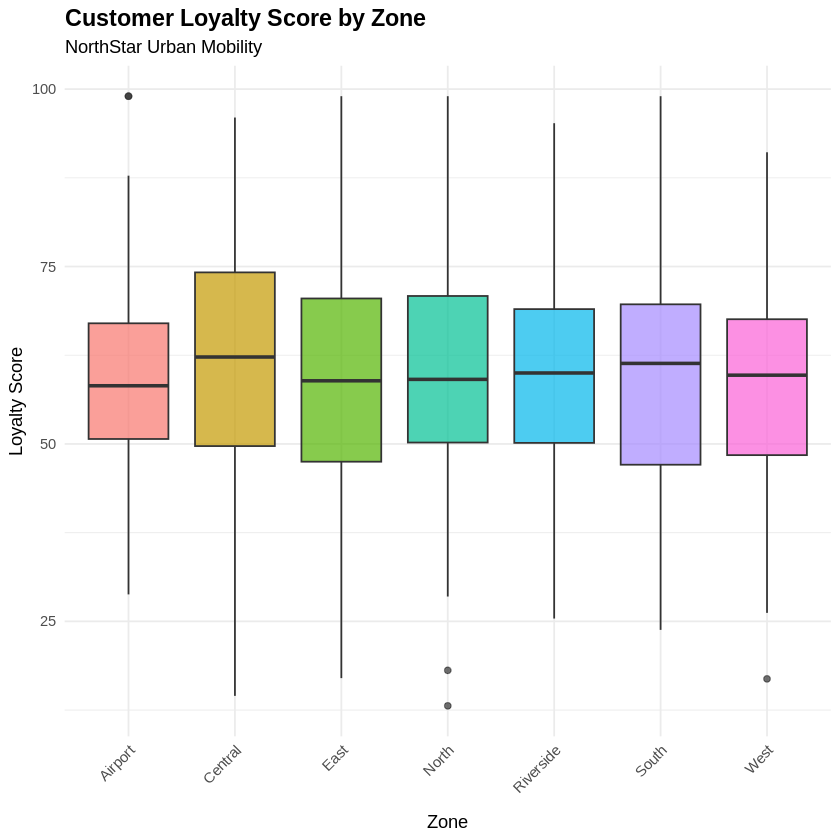

In [10]:
# boxplot showing loyalty score distribution per zone

ggplot(customers, aes(x=home_zone, y=loyalty_score, fill=home_zone)) +
  geom_boxplot(alpha=0.7) +
  labs(title="Customer Loyalty Score by Zone",
       subtitle="NorthStar Urban Mobility",
       x="Zone",
       y="Loyalty Score") +
  theme_minimal() +
  theme(plot.title=element_text(face="bold", size=14),
        axis.text.x=element_text(angle=45, hjust=1),
        legend.position="none")

## Statistical Summary
Key statistics from the analysis to support findings.

In [11]:
# statistical summary of key metrics

cat("======================================\n")
cat("   KEY STATISTICS SUMMARY\n")
cat("======================================\n\n")

cat("DELIVERY PERFORMANCE:\n")
cat("  Average route distance:",
    round(mean(deliveries$route_distance_km), 2), "km\n")
cat("  Average fuel cost:",
    round(mean(deliveries$fuel_or_charge_cost), 2), "\n")
cat("  Average customer rating:",
    round(mean(deliveries$customer_rating_post_delivery,
               na.rm=TRUE), 2), "\n\n")

cat("DRIVER STATISTICS:\n")
cat("  Average driver rating:",
    round(mean(drivers$driver_rating), 2), "\n")
cat("  Average training score:",
    round(mean(drivers$training_score, na.rm=TRUE), 2), "\n")
cat("  Average experience (years):",
    round(mean(drivers$years_experience), 2), "\n\n")

cat("CUSTOMER STATISTICS:\n")
cat("  Average loyalty score:",
    round(mean(customers$loyalty_score, na.rm=TRUE), 2), "\n")
cat("  Average app engagement:",
    round(mean(customers$app_engagement_score), 2), "\n\n")

cat("COMPLAINTS:\n")
cat("  Average resolution days:",
    round(mean(complaints$resolution_days, na.rm=TRUE), 2), "\n")
cat("  Average compensation:",
    round(mean(complaints$compensation_amount, na.rm=TRUE), 2), "\n")
cat("======================================\n")

   KEY STATISTICS SUMMARY

DELIVERY PERFORMANCE:
  Average route distance: 13.91 km
  Average fuel cost: 12.84 
  Average customer rating: 3.86 

DRIVER STATISTICS:
  Average driver rating: 4.17 
  Average training score: 74.91 
  Average experience (years): 8.22 

CUSTOMER STATISTICS:
  Average loyalty score: 59.69 
  Average app engagement: 58.13 

COMPLAINTS:
  Average resolution days: 7.93 
  Average compensation: 20.26 


## Key Statistical Observations

1. Customer post-delivery rating of 3.86/5 is concerning.
   It shows customers are not satisfied with the service.

2. Complaint resolution takes almost 8 days on average.
   This is too slow and likely causes more dissatisfaction.

3. Driver training score of 74.91 suggests there is room
   for improvement in driver training programmes.

4. Customer loyalty score of 59.69 is only just above
   halfway which means NorthStar is at risk of losing
   customers to competitors.

5. App engagement of 58.13 suggests customers are not
   fully utilising the mobile platform which NorthStar
   has invested heavily in.